# Movie Data Analysis

## Import Libiaries

In [1]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
movie = pd.read_csv("movies_dataset.csv")

## Data Overview

In [3]:
movie.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [10]:
movie.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  str    
 2   Genre                 999999 non-null  str    
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  str    
 5   Country               999999 non-null  str    
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  Director   

In [11]:
movie.shape

(999999, 17)

## Data Quality Assessment

In [12]:
movie.isnull().sum()

MovieID                 0
Title                   0
Genre                   0
ReleaseYear             0
ReleaseDate             0
Country                 0
BudgetUSD               0
US_BoxOfficeUSD         0
Global_BoxOfficeUSD     0
Opening_Day_SalesUSD    0
One_Week_SalesUSD       0
IMDbRating              0
RottenTomatoesScore     0
NumVotesIMDb            0
NumVotesRT              0
Director                0
LeadActor               0
dtype: int64

In [81]:
movie.duplicated().sum()

np.int64(0)

In [19]:
(movie[["BudgetUSD",
        "US_BoxOfficeUSD",
        "Global_BoxOfficeUSD",
        "Opening_Day_SalesUSD",
        "One_Week_SalesUSD"]
    ] < 0).sum()

BudgetUSD               0
US_BoxOfficeUSD         0
Global_BoxOfficeUSD     0
Opening_Day_SalesUSD    0
One_Week_SalesUSD       0
dtype: int64

## Data Preparation

In [15]:
movie.dtypes

MovieID                   int64
Title                       str
Genre                       str
ReleaseYear               int64
ReleaseDate                 str
Country                     str
BudgetUSD               float64
US_BoxOfficeUSD         float64
Global_BoxOfficeUSD     float64
Opening_Day_SalesUSD    float64
One_Week_SalesUSD       float64
IMDbRating              float64
RottenTomatoesScore       int64
NumVotesIMDb              int64
NumVotesRT                int64
Director                    str
LeadActor                   str
dtype: object

In [23]:
movie.nunique()

MovieID                 999999
Title                     9665
Genre                        8
ReleaseYear                 76
ReleaseDate              27757
Country                     10
BudgetUSD               988182
US_BoxOfficeUSD         999610
Global_BoxOfficeUSD     998527
Opening_Day_SalesUSD    997984
One_Week_SalesUSD       999219
IMDbRating                  91
RottenTomatoesScore        101
NumVotesIMDb             70288
NumVotesRT               30945
Director                   150
LeadActor                  299
dtype: int64

In [4]:
# Convert "ReleaseDate" to datetime data type
movie["ReleaseDate"] = pd.to_datetime(movie["ReleaseDate"], format="%d-%m-%Y")

# Convert "Genre" to a category data type
movie["Genre"] = movie["Genre"].astype("category")

In [5]:
movie.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   MovieID               999999 non-null  int64         
 1   Title                 999999 non-null  str           
 2   Genre                 999999 non-null  category      
 3   ReleaseYear           999999 non-null  int64         
 4   ReleaseDate           999999 non-null  datetime64[us]
 5   Country               999999 non-null  str           
 6   BudgetUSD             999999 non-null  float64       
 7   US_BoxOfficeUSD       999999 non-null  float64       
 8   Global_BoxOfficeUSD   999999 non-null  float64       
 9   Opening_Day_SalesUSD  999999 non-null  float64       
 10  One_Week_SalesUSD     999999 non-null  float64       
 11  IMDbRating            999999 non-null  float64       
 12  RottenTomatoesScore   999999 non-null  int64         
 13  NumVotesIM

## Adding required columns for data analysis

In [6]:
# Adding a "Profit" column

movie["Profit"] = movie["Global_BoxOfficeUSD"] - movie["BudgetUSD"]
movie.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,Profit
0,1,Might toward capital,Comedy,2003,2003-09-28,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick,8894607.87
1,2,He however experience,Comedy,1988,1988-02-14,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena,1753921.02
2,3,Star responsibility politics,Comedy,1971,1971-11-02,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley,4697031.95
3,4,Exactly live,Comedy,1998,1998-08-06,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett,2926508.80
4,5,Focus improve especially,Documentary,2021,2021-12-17,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS,2212101.52


In [31]:
# Before adding a "ROI" column, checking the denominator to prevent ZeroDivisionError
(movie['BudgetUSD'] == 0).sum()

np.int64(0)

In [7]:
# Adding a "ROI" column

movie["ROI"] = (movie["Profit"] / movie["BudgetUSD"]) * 100
movie.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,Profit,ROI
0,1,Might toward capital,Comedy,2003,2003-09-28,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick,8894607.87,135.229274
1,2,He however experience,Comedy,1988,1988-02-14,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena,1753921.02,93.104980
2,3,Star responsibility politics,Comedy,1971,1971-11-02,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley,4697031.95,190.311226
3,4,Exactly live,Comedy,1998,1998-08-06,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett,2926508.80,202.203111
4,5,Focus improve especially,Documentary,2021,2021-12-17,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS,2212101.52,245.539192


In [34]:
movie.columns.tolist()

['MovieID',
 'Title',
 'Genre',
 'ReleaseYear',
 'ReleaseDate',
 'Country',
 'BudgetUSD',
 'US_BoxOfficeUSD',
 'Global_BoxOfficeUSD',
 'Opening_Day_SalesUSD',
 'One_Week_SalesUSD',
 'IMDbRating',
 'RottenTomatoesScore',
 'NumVotesIMDb',
 'NumVotesRT',
 'Director',
 'LeadActor',
 'Profit',
 'ROI']

## Exploratory Data Analysis

### Q1. How are budget, revenue, profit, and ROI distributed?

In [44]:
movie[['BudgetUSD',
       'Global_BoxOfficeUSD',
       'Profit',
       'ROI']].describe()

,BudgetUSD,Global_BoxOfficeUSD,Profit,ROI
count,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000
mean,9.802824e+06,2.720625e+07,1.740343e+07,177.847438
std,2.249421e+07,6.954294e+07,5.040488e+07,125.705810
min,1.000000e+05,1.000000e+05,0.000000e+00,0.000000
25%,1.190511e+06,2.762370e+06,8.291324e+05,62.578072
50%,3.265790e+06,8.090223e+06,3.971480e+06,175.135841
75%,9.002791e+06,2.355245e+07,1.394296e+07,287.622887
max,3.000000e+08,1.499497e+09,1.199497e+09,399.999870


In [45]:
movie[['BudgetUSD',
       'Global_BoxOfficeUSD',
       'Profit',
       'ROI']].skew()

BudgetUSD              6.911884
Global_BoxOfficeUSD    8.515599
Profit                 9.419169
ROI                    0.087462
dtype: float64

**Insight:**
- The right-skewed (or positively skewed) distribution is occoured among budget, revenue, and profit.
- That means a relatively small number of movies have extremely large budgets/revenues/profits and pull the mean upward.
- ROI is approximately symmetric, suggesting a different distribution pattern from the other financial metrics.

### Outlier Analysis

In [47]:
movie[['BudgetUSD', 'Global_BoxOfficeUSD', 'Profit', 'ROI']].quantile(
    [0.25, 0.50, 0.75]
)

Q1 = movie[['BudgetUSD', 'Global_BoxOfficeUSD', 'Profit', 'ROI']].quantile(0.25)
Q3 = movie[['BudgetUSD', 'Global_BoxOfficeUSD', 'Profit', 'ROI']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (movie[['BudgetUSD', 'Global_BoxOfficeUSD', 'Profit', 'ROI']] < lower_bound) |
    (movie[['BudgetUSD', 'Global_BoxOfficeUSD', 'Profit', 'ROI']] > upper_bound)
).sum()

outlier_counts

BudgetUSD              109157
Global_BoxOfficeUSD    113298
Profit                 118280
ROI                         0
dtype: int64

**Insight:** The IQR method identifies a large number of statistical outliers in financial metrics, reflecting the highly right-skewed distribution of movie budgets, revenue, and profit.
These outliers likely represent movies with exceptionally large financial values rather than necessarily data-quality errors.

### Q2. Does a higher budget lead to higher revenue?

In [71]:
budget_revenue_corr = movie["BudgetUSD"].corr(movie["Global_BoxOfficeUSD"])
print(f"Budget VS Revenue Correlation: {budget_revenue_corr:.3f}")

Budget VS Revenue Correlation: 0.895


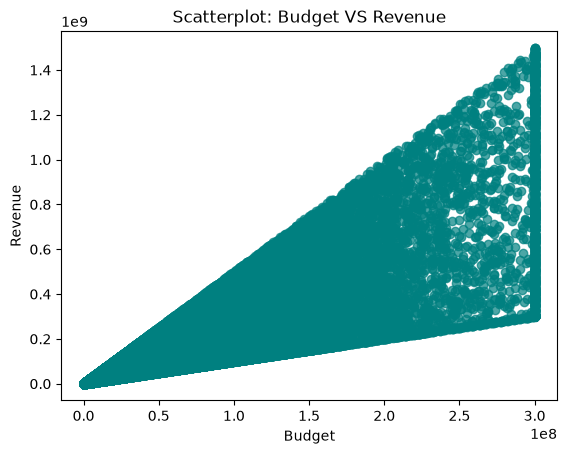

In [76]:
# Visualization

plt.scatter(movie["BudgetUSD"], movie["Global_BoxOfficeUSD"], alpha=0.7, color="teal")
plt.title("Scatterplot: Budget VS Revenue", color="black")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

**Insight:** Budget has a strong positive relationship with revenue, indicating that higher-budget movies generally generate higher revenues. However, correlation does not establish that increasing the budget directly causes higher revenue.

### Q3. Does a higher budget lead to higher ROI?

In [74]:
budget_roi_corr = movie["BudgetUSD"].corr(movie["ROI"])
print(f"Budget VS ROI Correlation: {budget_roi_corr:.3f}")

Budget VS ROI Correlation: -0.001


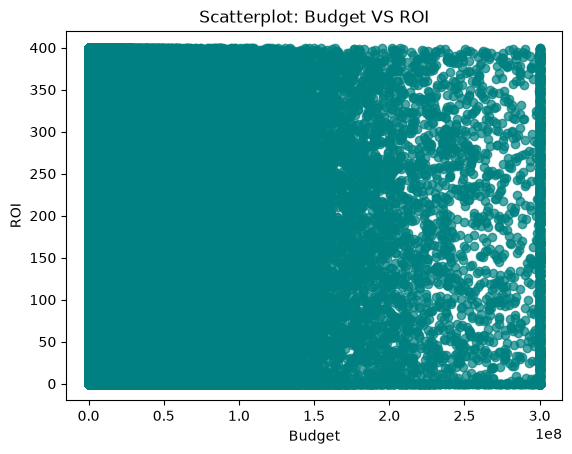

In [75]:
# Visualization

plt.scatter(movie["BudgetUSD"], movie["ROI"], alpha=0.7, color="teal")
plt.title("Scatterplot: Budget VS ROI", color="black")
plt.xlabel("Budget")
plt.ylabel("ROI")
plt.show()

**Insight:** Budget has virtually no linear relationship with ROI. Therefore, a higher production budget does not guarantee a higher return on investment.

### Q4. How many movies are profitable vs unprofitable?

In [67]:
def profitability(profit):
    if profit > 0:
        return "Profitable"
    elif profit == 0:
        return "Break-Even"
    else:
        return "Unprofitable"

movie["Profitability"] = movie["Profit"].apply(profitability)
movie["Profitability"].value_counts(normalize=True) * 100

Profitability
Profitable    88.930789
Break-Even    11.069211
Name: proportion, dtype: float64

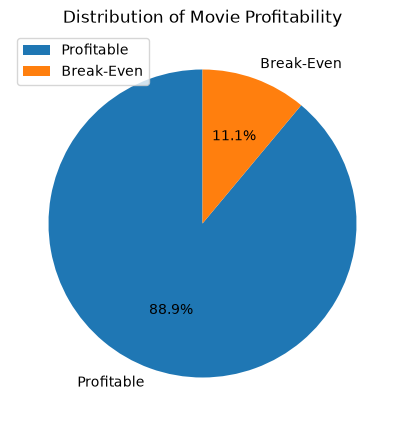

In [80]:
# Visualization

# Calculate the counts of each category
category_counts = movie["Profitability"].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 5))
plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Movie Profitability")
plt.legend()
plt.show()

**Insight:** Approximately 88.9% of movies generated positive profit, while 11.1% reached break-even with no recorded loss.

### Q5. Which genres generate the highest profit?
### Which genres generate the highest ROI?
### Which genres have the strongest audience engagement?

In [21]:
genre_performance = movie.groupby("Genre").agg(
    movie_count = ("MovieID", "count"),
    avg_budget = ("BudgetUSD", "mean"),
    avg_revenue = ("Global_BoxOfficeUSD", "mean"),
    avg_profit = ("Profit", "mean"),
    avg_roi = ("ROI", "mean"),
    avg_imdb_rating = ("IMDbRating", "mean"),
    avg_imdb_votes = ("NumVotesIMDb", "mean")
)

genre_performance

,movie_count,avg_budget,avg_revenue,avg_profit,avg_roi,avg_imdb_rating,avg_imdb_votes
Genre,,,,,,,
Action,150131,9.615741e+06,2.684386e+07,1.722812e+07,178.402891,6.495995,9126.336559
Comedy,199832,9.826522e+06,2.721993e+07,1.739341e+07,177.926932,6.499408,9191.334176
Documentary,50114,9.931104e+06,2.758178e+07,1.765067e+07,177.510549,6.500856,9150.601908
Drama,250018,9.794142e+06,2.715240e+07,1.735826e+07,177.517105,6.487393,9151.186359
Horror,100010,9.879427e+06,2.748073e+07,1.760131e+07,178.639376,6.499671,9198.992621
Romance,100021,9.844204e+06,2.728314e+07,1.743894e+07,177.427866,6.491912,9078.304746
Sci-Fi,49802,9.779042e+06,2.697233e+07,1.719329e+07,177.724066,6.498530,9056.369162
Thriller,100071,9.887535e+06,2.743435e+07,1.754682e+07,177.538701,6.495319,9040.920007


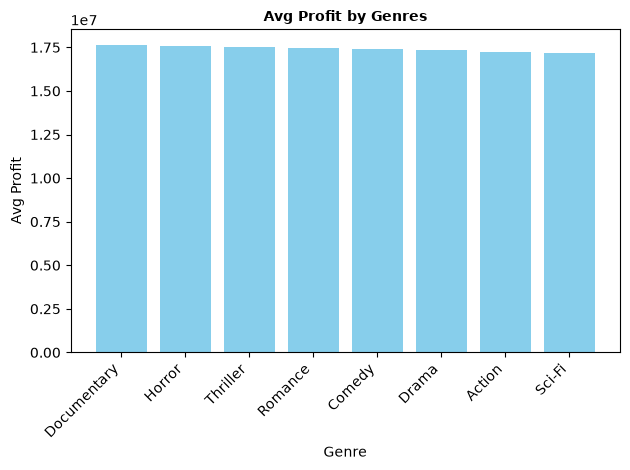

In [22]:
# Visualization for the highest Profit by Genres

profit_performance = genre_performance.sort_values("avg_profit", ascending=False)

plt.bar(profit_performance.index, profit_performance["avg_profit"], color="skyblue")
plt.xticks(ticks=profit_performance.index, labels=profit_performance.index, rotation=45, ha='right')
plt.title("Avg Profit by Genres", fontsize=10, fontweight="bold")
plt.ylabel("Avg Profit")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()

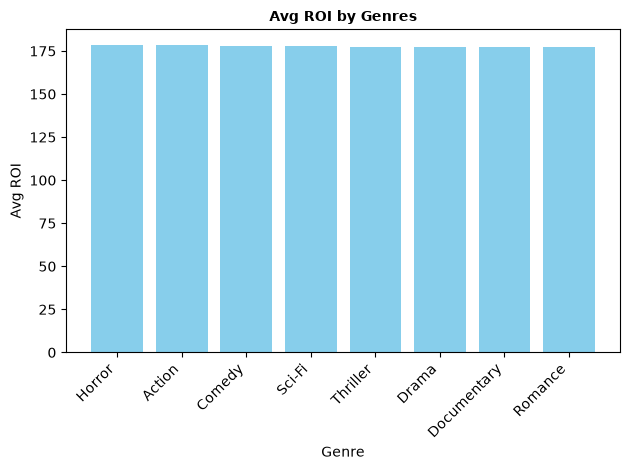

In [23]:
# Visualization for the highest ROI by genres

roi_performance = genre_performance.sort_values("avg_roi", ascending=False)

plt.bar(roi_performance.index, roi_performance["avg_roi"], color="skyblue")
plt.xticks(ticks=roi_performance.index, labels=roi_performance.index, rotation=45, ha='right')
plt.title("Avg ROI by Genres", fontsize=10, fontweight="bold")
plt.ylabel("Avg ROI")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()

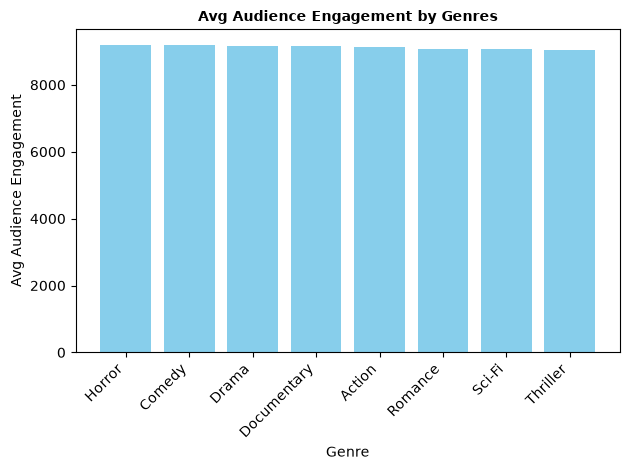

In [26]:
# Visualization for the strongest audience engagement by genres

audience_engagement = genre_performance.sort_values("avg_imdb_votes", ascending=False)

plt.bar(audience_engagement.index, audience_engagement["avg_imdb_votes"], color="skyblue")
plt.xticks(ticks=audience_engagement.index, labels=audience_engagement.index, rotation=45, ha='right')
plt.title("Avg Audience Engagement by Genres", fontsize=10, fontweight="bold")
plt.ylabel("Avg Audience Engagement")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()

**Insight:** Documentary movies have the highest average profit, while Horror achieves the highest average ROI and average IMDb votes. However, financial performance is relatively consistent across genres, suggesting that genre alone is not a strong differentiator of profitability in this dataset.

### Q6. How have movie production and profitability changed over time?

In [32]:
yearly_performance = (
    movie.groupby("ReleaseYear")
    .agg(
        movie_count=("MovieID", "count"),
        avg_budget=("BudgetUSD", "mean"),
        avg_profit=("Profit", "mean")
    )
    .sort_index()
)

yearly_performance

,movie_count,avg_budget,avg_profit
ReleaseYear,,,
1950,2432,1.096492e+07,1.865391e+07
1951,2613,9.993369e+06,1.773238e+07
1952,2960,9.321035e+06,1.700050e+07
1953,3235,9.377751e+06,1.727671e+07
1954,3496,1.054117e+07,1.968091e+07
...,...,...,...
2021,22809,9.802317e+06,1.746442e+07
2022,22812,9.698474e+06,1.732534e+07
2023,23348,1.004971e+07,1.796583e+07


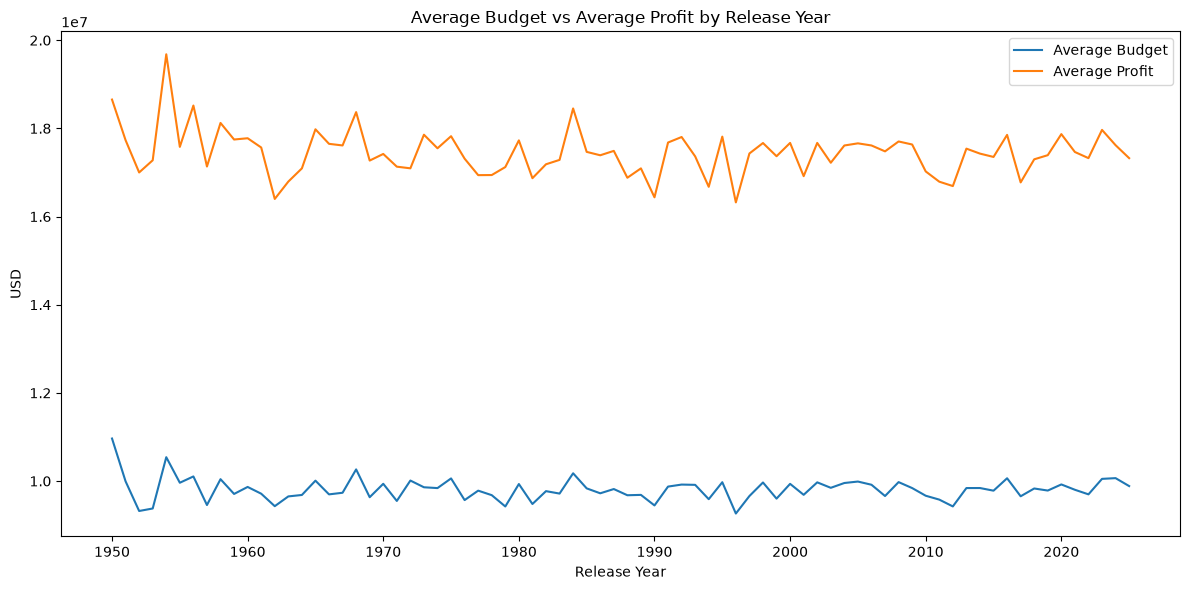

In [37]:
# Visualization

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_performance.index,
    yearly_performance["avg_budget"],
    label="Average Budget"
)

plt.plot(
    yearly_performance.index,
    yearly_performance["avg_profit"],
    label="Average Profit"
)

plt.title("Average Budget vs Average Profit by Release Year")
plt.xlabel("Release Year")
plt.ylabel("USD")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
budget_change = (
    (yearly_performance["avg_budget"].iloc[-1] /
     yearly_performance["avg_budget"].iloc[0]) - 1
) * 100

profit_change = (
    (yearly_performance["avg_profit"].iloc[-1] /
     yearly_performance["avg_profit"].iloc[0]) - 1
) * 100

print(f"Average budget change: {budget_change:.2f}%")
print(f"Average profit change: {profit_change:.2f}%")

Average budget change: -9.84%
Average profit change: -7.12%


**Insight:** Average movie budgets and profits remained relatively stable over time, despite year-to-year fluctuations. From 1950 to 2025, average budget decreased by 9.84% while average profit decreased by 7.12%, suggesting no strong long-term growth trend in the dataset.

## Final Findings

- Production budget has a strong positive relationship with global box-office revenue.
- Higher production budgets do not guarantee higher ROI.
- Most movies in the dataset are profitable, although profitability varies substantially across individual movies.
- Financial performance is relatively consistent across genres, with Documentary showing the highest average profit and Horror showing the highest average ROI.
- Horror has the highest average number of IMDb votes, indicating stronger audience interaction on IMDb in this dataset.
- Average movie budgets and profits remained relatively stable over the period analyzed.

## Recommendations

- Do not assume that increasing a movie's budget will automatically lead to higher returns.
- Monitor ROI separately from revenue because high revenue does not necessarily indicate efficient investment.
- Consider genre performance together with audience engagement when evaluating movie investment opportunities.
- Use additional audience and market variables to improve investment decisions.

## Limitations

- IMDb votes measure audience interaction on IMDb and do not represent total movie audience engagement across all platforms.
- Financial metrics are highly right-skewed, so average values may be influenced by a relatively small number of very successful movies.
- The analysis is based on the available dataset and may not represent the entire movie industry.